# JAX Tutorial

# Warm up

In [21]:
import jax.numpy as jnp
import numpy as np

# Special transform functions
from jax import grad, jit, vmap, pmap

# Jax's low level API
# Lax is an anagram of XLA
from jax import lax

from jax import make_jaxpr
from jax import random
from jax import device_count
import matplotlib.pyplot as plt

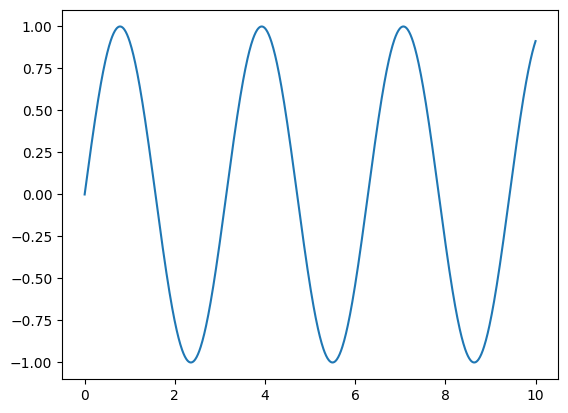

In [22]:
x_np = np.linspace(0, 10, 1000)
y_np = 2*np.sin(x_np)*np.cos(x_np)
plt.plot(x_np, y_np)

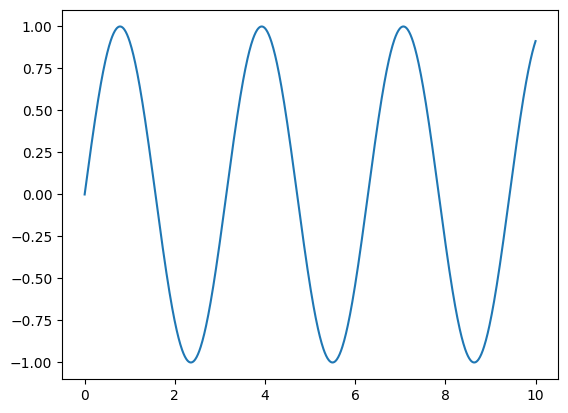

In [23]:
# 1. JAX is similar to numpy
x_jnp = np.linspace(0, 10, 1000)
y_jnp = 2*np.sin(x_jnp)*np.cos(x_jnp)
plt.plot(x_jnp, y_jnp)

In [24]:
# 2. Jax arrays are immutable! (functional programming)

size = 10
index = 0
value = 23

# Numpy is mutable 
x = np.arange(size)
print(x)
x[index] = value
print(x)

[0 1 2 3 4 5 6 7 8 9]
[23  1  2  3  4  5  6  7  8  9]


In [25]:
# JAX is immutable
x = jnp.arange(size)
print(x)
x[index] = value
print(x)

[0 1 2 3 4 5 6 7 8 9]


TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

In [28]:
# Solutions
y = x.at[index].set(value)
print(x)
print(y)

[0 1 2 3 4 5 6 7 8 9]
[23  1  2  3  4  5  6  7  8  9]


In [34]:
# 3. Jax handles random numbers differently
seed = 23
key = random.PRNGKey(seed)

x = random.normal(key, (10,))
print(type(x), x)

<class 'jaxlib._jax.ArrayImpl'> [ 0.43111357 -0.7181069  -0.00301107 -0.03809918 -0.39300123 -0.15450643
 -0.6902867  -0.8813932  -1.0635357   0.7590283 ]


In [ ]:
# 4. Jax is AI accelerator agnostic. Same code runs everywhere

size = 3000

# Data is automagically pushed to the AI accelerator
# No need for ".to(device)" like Pytorch
x_jnp = random.normal(key, (size, size), dtype=jnp.float32)
x_jnp = np.random.normal(size = (size, size).astype(np.float32)) # some diff in API exists!

%timeit jnp.dot(x_jnp, x_jnp.T).block_until_ready() #1) on GPU fast